# Enrichment / enhancement metrics — virus intensity on CD31 vessels

The specificity question is "**is the virus concentrated on the vasculature?**"
The soundest way to ask it is *not* to segment the virus at all. Define vessels
from CD31 (the ground-truth endothelial stain) and measure whether the virus is
**brighter on vessels than off them**. This avoids the near-tautology of
segmenting the virus into tubes and then asking whether it looks tubular (the
issue flagged at the end of `dice_between_channels.ipynb`).

All code reuses the merged `scripts/`, so the numbers match the command-line
tools.

## Method A — threshold-free CD31 percentile  *(primary)*

Call the top **q%** of CD31 intensity within tissue "vessel", and compute

$$\text{enrichment}(q) = \frac{\text{mean virus where CD31 is in its top } q\%}{\text{mean virus in the rest of the tissue}}$$

Sweep $q \in \{2,5,10,20,30\}$. There is no vesselness filter and no threshold on a
response — the only real knob is $q$ (with a light speck-cleanup that drops
components below ~8 µm², smaller than a capillary, so isolated bright-CD31 noise is
not counted as vessel). $q$ is swept, so a regional ordering that holds **across
$q$** is a property of the data, not of where a line was drawn. Enrichment is a
ratio of virus intensities, so a per-section brightness gain cancels: it is truly
threshold-free on the virus side.

## Method B — CD31 vessel mask  *(secondary, robustness check)*

Segment CD31 with the Jerman pipeline and measure the virus inside vs outside:

- **enrichment** = mean virus in vessels / mean virus in parenchyma,
- **coverage** = fraction of vessel area that is virus-positive (how much of the
  vasculature the virus reaches),
- **off_target** = fraction of virus-positive area lying *off* vessels
  (parenchymal leak).

"virus-positive" is set per image from its own parenchyma (median + 3·MAD),
because acquisition brightness was tuned per image.

> ⚠️ **Caveat.** On this dataset the mask pipeline's calibrated `reference_lambda`
> (~0.5) saturates the Jerman response, so the CD31 "vessel" mask covers **~45% of
> the tissue** — essentially grey matter, not vessels. Treat Method B as a
> cross-check on the regional **ordering**, not as the source of the enrichment
> magnitude. Method A is the measure to quote.

In [1]:
# Bootstrap: walk up to the repo root (the folder with pyproject.toml) and put it
# and scripts/ on sys.path, so this notebook runs from a plain clone with no
# install step -- the same pattern the archive notebooks use.
import sys
from pathlib import Path

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
for _p in (str(_root), str(_root / "scripts")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
pd.set_option("display.width", 120)

from enrichment_by_cd31_percentile import PERCENTILES, coverage_curve, enrichment_curve
from analyse_spinal_cord import (NAME, REGION_NAME, analyse, calibrate_reference,
                                 curated_paths, tissue_mask, vessel_mask)
from visualize_sections import VIS_Q, top_q_mask, _result_rgb
from zoom_crops import CROP_PX, _add_scalebar, _crop_slice, _merge_rgb
from scipy.ndimage import uniform_filter

# visualize_sections and zoom_crops set matplotlib to the non-interactive Agg
# backend on import, which silences plt.show(); re-assert the inline backend here,
# after the imports, so figures render in the notebook.
%matplotlib inline

RUN_FULL = False   # flip to run every section

In [2]:
paths = curated_paths() if RUN_FULL else curated_paths(pilot_mice=2, slices_per_region=1)
print(f"{len(paths)} sections ({'full dataset' if RUN_FULL else 'pilot'})")

10 sections (pilot)


### Method A — percentile enrichment (fast; no segmentation)

In [3]:
rows = []
for path in paths:
    figure, mouse, region, reporter, slice_id = NAME.match(path.name).groups()
    reporter = "SYFP2" if "SYFP2" in reporter else ("tdT" if "tdT" in reporter else reporter)
    stack = tifffile.imread(path)
    if stack.ndim != 3 or stack.shape[0] != 2:
        continue
    virus, cd31 = stack[0].astype(np.float32), stack[1].astype(np.float32)
    try:
        tissue = tissue_mask(virus, cd31)
    except ValueError as error:
        print(f"skip {path.name}: {error}")
        continue
    curve = enrichment_curve(virus, cd31, tissue)
    rows.append(dict(figure=figure, reporter=reporter, mouse=mouse, region=region,
                     slice=slice_id or "", **{f"q{q}": curve[q] for q in PERCENTILES}))

pct = pd.DataFrame(rows)
pct.round(3)

,figure,reporter,mouse,region,slice,q2,q5,q10,q20,q30
0,Fig 1,SYFP2,M131,C,1,1.647,1.575,1.538,1.535,1.626
1,Fig 1,SYFP2,M131,L,11,1.360,1.264,1.219,1.197,1.220
2,Fig 1,SYFP2,M131,T,10,1.625,1.540,1.498,1.499,1.576
3,Fig 1,SYFP2,M132,C,1,1.731,1.617,1.570,1.502,1.503
4,Fig 1,SYFP2,M132,L,11,1.348,1.297,1.263,1.246,1.272
5,Fig 1,SYFP2,M132,T,6,1.647,1.623,1.584,1.619,1.804
6,Fig 2a,tdT,M63,C,10,4.632,3.512,2.717,2.104,1.929
7,Fig 2a,tdT,M63,L,3,3.402,3.108,2.900,2.477,2.212
8,Fig 2a,tdT,M63,T,1,3.573,3.434,3.021,2.523,2.312
9,Fig 2b,tdT,M87,TL,5,1.550,1.514,1.481,1.397,1.317


Aggregate: slices → mouse × region, then mean across mice, per reporter. A value
above 1 means the virus is brighter on CD31-bright vessels than elsewhere.

In [4]:
qcols = [f"q{q}" for q in PERCENTILES]
per_mouse = pct.groupby(["reporter", "mouse", "region"])[qcols].mean().reset_index()
region_mean = per_mouse.groupby(["reporter", "region"])[qcols].mean().round(3)
region_mean

q2     q5    q10    q20    q30
reporter region                                   
SYFP2    C       1.689  1.596  1.554  1.519  1.565
         L       1.354  1.280  1.241  1.222  1.246
         T       1.636  1.582  1.541  1.559  1.690
tdT      C       4.632  3.512  2.717  2.104  1.929
         L       3.402  3.108  2.900  2.477  2.212
         T       3.573  3.434  3.021  2.523  2.312
         TL      1.550  1.514  1.481  1.397  1.317

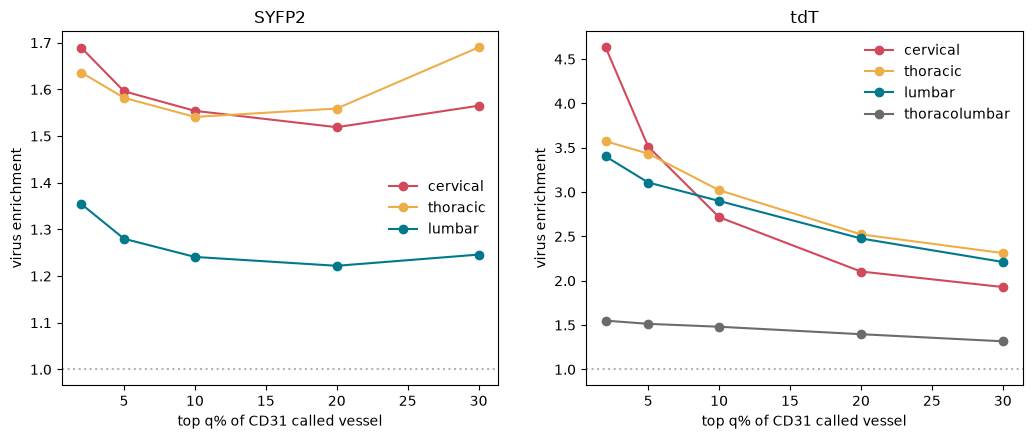

In [5]:
# Enrichment vs q, one line per region -- a line that stays lowest across the whole
# sweep is the robust part of the result.
colour = {"C": "#d1495b", "T": "#edae49", "L": "#00798c", "TL": "#6b6b6b"}
long = {"C": "cervical", "T": "thoracic", "L": "lumbar", "TL": "thoracolumbar"}
reporters = list(region_mean.index.get_level_values(0).unique())
fig, axes = plt.subplots(1, len(reporters), figsize=(6.2 * len(reporters), 4.6), squeeze=False)
for ax, reporter in zip(axes[0], reporters):
    for region in ["C", "T", "L", "TL"]:
        if (reporter, region) not in region_mean.index:
            continue
        ax.plot(PERCENTILES, region_mean.loc[(reporter, region), qcols].values,
                "-o", color=colour[region], label=long[region])
    ax.axhline(1.0, color="0.7", ls=":")
    ax.set_xlabel("top q% of CD31 called vessel"); ax.set_ylabel("virus enrichment")
    ax.set_title(reporter); ax.legend(frameon=False)
plt.show()

### Coverage — the area companion (same CD31 vessels)

Enrichment asks how much *brighter* the virus is on vessels; **coverage** asks how
much of the vasculature it actually *reaches* — the virus-positive fraction of the
top-*q%* CD31 vessels. Same threshold-free vessel geometry as enrichment, so the
two are directly comparable; "virus-positive" is the per-image rule (parenchyma
median + 3·MAD). This still never segments the virus — the vessel geometry is
CD31's, the virus only decides which of those vessels are labelled.

In [6]:
rows = []
for path in paths:
    figure, mouse, region, reporter, slice_id = NAME.match(path.name).groups()
    reporter = "SYFP2" if "SYFP2" in reporter else ("tdT" if "tdT" in reporter else reporter)
    stack = tifffile.imread(path)
    if stack.ndim != 3 or stack.shape[0] != 2:
        continue
    virus, cd31 = stack[0].astype(np.float32), stack[1].astype(np.float32)
    try:
        tissue = tissue_mask(virus, cd31)
    except ValueError:
        continue
    cov = coverage_curve(virus, cd31, tissue)
    rows.append(dict(reporter=reporter, mouse=mouse, region=region,
                     **{f"q{q}": cov[q] for q in PERCENTILES}))

coverage = pd.DataFrame(rows)
cover_region = (coverage.groupby(["reporter", "mouse", "region"])[qcols].mean().reset_index()
                        .groupby(["reporter", "region"])[qcols].mean().round(3))
cover_region

q2     q5    q10    q20    q30
reporter region                                   
SYFP2    C       0.119  0.074  0.052  0.035  0.039
         L       0.076  0.049  0.033  0.020  0.014
         T       0.157  0.136  0.151  0.268  0.477
tdT      C       0.574  0.488  0.378  0.264  0.224
         L       0.560  0.551  0.506  0.369  0.277
         T       0.464  0.507  0.442  0.330  0.283
         TL      0.334  0.298  0.283  0.248  0.208

Coverage tells the **same regional story** as enrichment — for SYFP2 lumbar is
lowest on both, so the virus is not only dimmer on lumbar vessels but reaches
fewer of them. Two independent readouts (intensity and area) from one CD31
vessel definition.

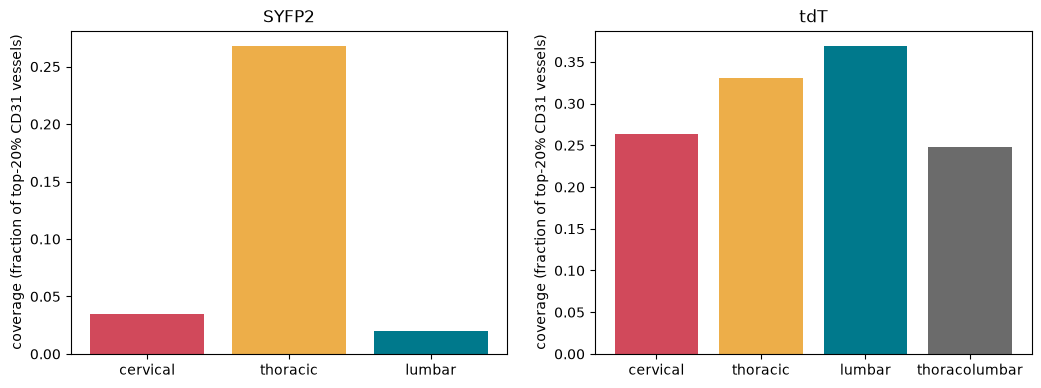

In [7]:
fig, axes = plt.subplots(1, len(reporters), figsize=(6.2 * len(reporters), 4.2),
                         squeeze=False)
for ax, reporter in zip(axes[0], reporters):
    present = [r for r in ["C", "T", "L", "TL"] if (reporter, r) in cover_region.index]
    ax.bar([long[r] for r in present],
           [cover_region.loc[(reporter, r), f"q{VIS_Q}"] for r in present],
           color=[colour[r] for r in present])
    ax.set_ylabel(f"coverage (fraction of top-{VIS_Q}% CD31 vessels)")
    ax.set_title(reporter)
plt.show()

### Method B — CD31 vessel mask (enrichment, coverage, off-target)

In [8]:
reference = calibrate_reference(paths, n_sections=min(6, len(paths)))

rows = []
for path in paths:
    figure, mouse, region, reporter, slice_id = NAME.match(path.name).groups()
    reporter = "SYFP2" if "SYFP2" in reporter else ("tdT" if "tdT" in reporter else reporter)
    try:
        m = analyse(path, reference)
    except Exception as error:
        print(f"skip {path.name}: {error}")
        continue
    rows.append(dict(reporter=reporter, mouse=mouse, region=region,
                     enrichment=m["enrichment"], coverage=m["coverage"],
                     off_target=m["off_target"], vessel_area_fraction=m["vessel_area_fraction"]))

mask = pd.DataFrame(rows)
mask.round(3)

   Fig 1_M131_C_SYFP2-green_CD31-mag_slice1.tif   lambda_max       0.6


   Fig 1_M131_L_SYFP2-green_CD31-mag_slice11.tif  lambda_max       0.5


   Fig 1_M131_T_SYFP2-green_CD31-mag_slice10.tif  lambda_max       0.5


   Fig 1_M132_C_SYFP2-green_CD31-mag_slice1.tif   lambda_max       0.6


   Fig 1_M132_L_SYFP2-green_CD31-mag_slice11.tif  lambda_max       0.5


   Fig 1_M132_T_SYFP2-green_CD31-mag_slice6.tif   lambda_max       0.7
   -> dataset reference_lambda = 0.6 (median of 6; spread 1-1)


,reporter,mouse,region,enrichment,coverage,off_target,vessel_area_fraction
0,SYFP2,M131,C,1.425,0.034,0.100,0.426
1,SYFP2,M131,L,1.166,0.009,0.026,0.501
2,SYFP2,M131,T,1.415,0.221,0.345,0.410
3,SYFP2,M132,C,1.324,0.017,0.003,0.444
4,SYFP2,M132,L,1.192,0.007,0.032,0.489
5,SYFP2,M132,T,1.478,0.440,0.385,0.422
6,tdT,M63,C,2.017,0.223,0.218,0.479
7,tdT,M63,L,2.153,0.230,0.132,0.424
8,tdT,M63,T,2.289,0.262,0.217,0.407
9,tdT,M87,TL,1.188,0.139,0.126,0.540


Note the **`vessel_area_fraction` ≈ 0.4–0.5** column: the CD31 mask is capturing
nearly half the tissue, the over-segmentation warned about above. The enrichment
*ordering* by region can still be compared to Method A, but the magnitude is not
a vessel-vs-parenchyma contrast at this operating point.

In [9]:
mask.groupby(["reporter", "region"])[["enrichment", "coverage", "off_target",
                                       "vessel_area_fraction"]].mean().round(3)

enrichment  coverage  off_target  vessel_area_fraction
reporter region                                                        
SYFP2    C            1.375     0.026       0.052                 0.435
         L            1.179     0.008       0.029                 0.495
         T            1.446     0.331       0.365                 0.416
tdT      C            2.017     0.223       0.218                 0.479
         L            2.153     0.230       0.132                 0.424
         T            2.289     0.262       0.217                 0.407
         TL           1.188     0.139       0.126                 0.540

## Visual check — Method A on one section

Dim grey virus everywhere; pixels on the top-*q%* CD31 vessels tinted green in
proportion to the virus intensity there. A vessel bed the virus reaches glows;
one it misses stays dark. The enrichment number is that contrast, quantified.

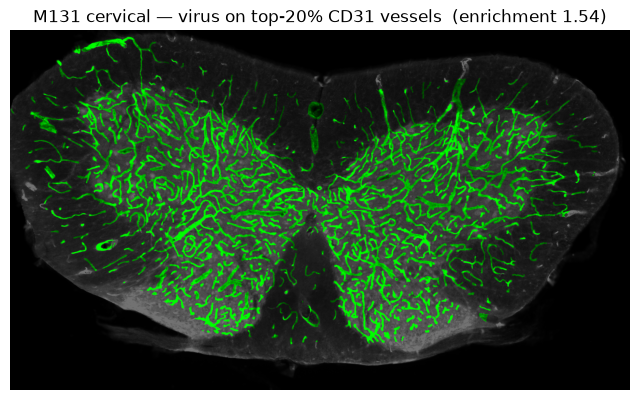

In [10]:
path = paths[0]
stack = tifffile.imread(path)
virus, cd31 = stack[0].astype(np.float32), stack[1].astype(np.float32)
tissue = tissue_mask(virus, cd31)
vessels = top_q_mask(cd31, tissue, VIS_Q)
curve = enrichment_curve(virus, cd31, tissue)

d = np.s_[::2, ::2]
figure, mouse, region, reporter, slice_id = NAME.match(path.name).groups()
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(_result_rgb(virus[d], tissue[d], vessels[d]))
ax.set_title(f"{mouse} {REGION_NAME[region]} — virus on top-{VIS_Q}% CD31 vessels"
             f"  (enrichment {curve[VIS_Q]:.2f})")
ax.axis("off")
plt.show()

## Close-up — virus on the CD31 vessels

Zoom into the densest-vessel window at **native resolution**: the virus channel,
the CD31 channel, and their merge (virus green, CD31 magenta) with the top-*q%*
vessel outline. Where the virus reaches a vessel the two channels overlap and read
white/yellow; diffuse green between vessels is parenchymal virus.

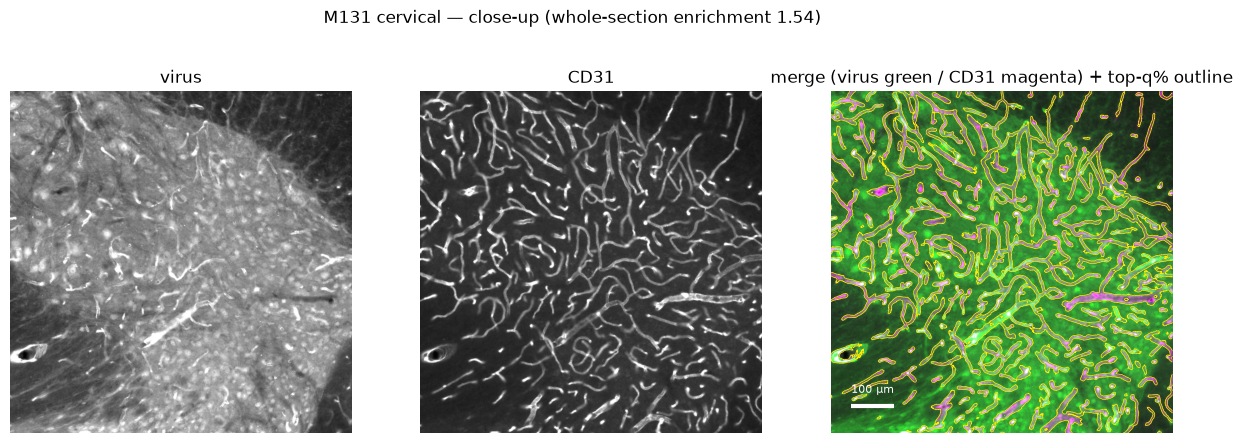

In [11]:
# Zoom into the densest-vessel window of the same section at native resolution.
box = lambda a: uniform_filter(a.astype(np.float32), size=CROP_PX, mode="constant")
half = CROP_PX // 2
rows_, cols_ = tissue.shape
valid = np.zeros(tissue.shape, bool)
valid[half:rows_ - half, half:cols_ - half] = True
valid &= box(tissue.astype(np.float32)) > 0.6
centre = np.unravel_index(
    np.argmax(np.where(valid, box(vessels.astype(np.float32)), -np.inf)), tissue.shape)
sl = _crop_slice(centre)

def clip(channel):
    lo, hi = np.percentile(channel[tissue], [1, 99])
    return np.clip((channel - lo) / max(hi - lo, 1e-6), 0, 1)

vcrop, ccrop, ves = clip(virus)[sl], clip(cd31)[sl], vessels[sl]
fig, ax = plt.subplots(1, 3, figsize=(15, 5.2))
ax[0].imshow(vcrop, cmap="gray"); ax[0].set_title("virus")
ax[1].imshow(ccrop, cmap="gray"); ax[1].set_title("CD31")
ax[2].imshow(_merge_rgb(vcrop, ccrop))
ax[2].contour(ves.astype(float), [0.5], colors="#ffea00", linewidths=0.5)
_add_scalebar(ax[2]); ax[2].set_title("merge (virus green / CD31 magenta) + top-q% outline")
for a in ax:
    a.axis("off")
fig.suptitle(f"{mouse} {REGION_NAME[region]} — close-up "
             f"(whole-section enrichment {curve[VIS_Q]:.2f})")
plt.show()

## Comparison — cervical vs lumbar

The result, made visual. Densest-vessel close-ups of a cervical and a lumbar SYFP2
section; virus is tinted green on the top-*q%* vessels in proportion to its
intensity there. Cervical vessels carry more virus than lumbar — the enrichment
difference, by eye.

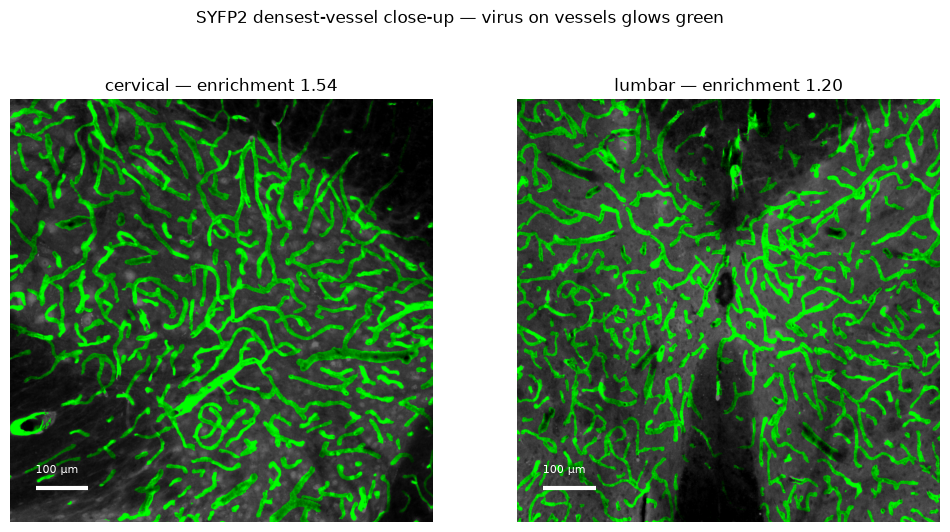

In [12]:
def densest_crop(path):
    stack = tifffile.imread(path)
    v, c = stack[0].astype(np.float32), stack[1].astype(np.float32)
    t = tissue_mask(v, c)
    ves = top_q_mask(c, t, VIS_Q)
    dense = uniform_filter(ves.astype(np.float32), size=CROP_PX, mode="constant")
    in_tissue = uniform_filter(t.astype(np.float32), size=CROP_PX, mode="constant")
    hlf = CROP_PX // 2
    ok = np.zeros(t.shape, bool); ok[hlf:t.shape[0] - hlf, hlf:t.shape[1] - hlf] = True
    ok &= in_tissue > 0.6
    ctr = np.unravel_index(np.argmax(np.where(ok, dense, -np.inf)), t.shape)
    s = _crop_slice(ctr)
    return _result_rgb(v[s], t[s], ves[s]), float(enrichment_curve(v, c, t)[VIS_Q])

syfp = [p for p in paths if "SYFP2" in NAME.match(p.name).group(4)]
cerv = next(p for p in syfp if NAME.match(p.name).group(3) == "C")
lumb = next(p for p in syfp if NAME.match(p.name).group(3) == "L")
fig, ax = plt.subplots(1, 2, figsize=(12, 6.2))
for a, p, name in [(ax[0], cerv, "cervical"), (ax[1], lumb, "lumbar")]:
    rgb, enrich = densest_crop(p)
    a.imshow(rgb); _add_scalebar(a); a.axis("off")
    a.set_title(f"{name} — enrichment {enrich:.2f}")
fig.suptitle("SYFP2 densest-vessel close-up — virus on vessels glows green")
plt.show()

## Comparison — Method A (percentile) vs Method B (Jerman mask)

The two vessel definitions on the *same* window. Method A (top-*q%* CD31) traces
the vessels; Method B (the Jerman mask) floods well past them — the ~45%-of-tissue
over-segmentation, concretely. This is why enrichment is quoted from Method A.

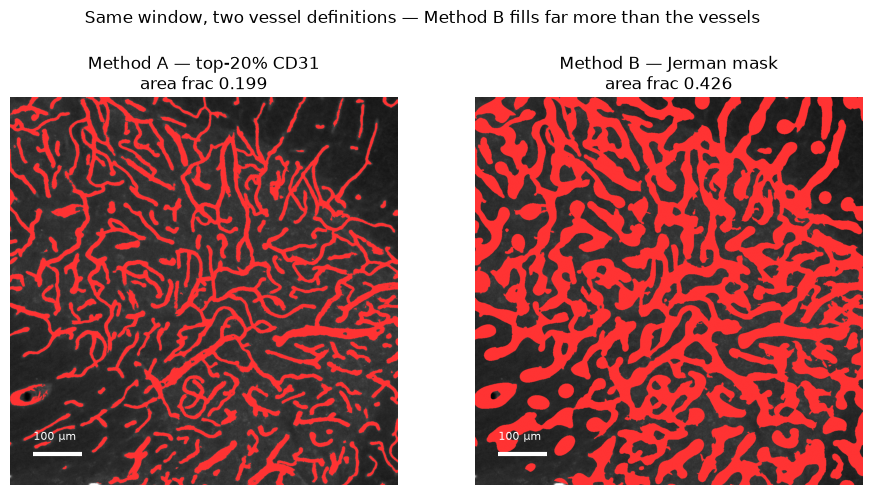

In [13]:
# Same window as the close-up; two vessel definitions overlaid on dim CD31.
mask_b = vessel_mask(cd31, tissue, reference)       # reference from the Method B cell
a_frac = vessels.sum() / tissue.sum()
b_frac = mask_b.sum() / tissue.sum()

base = clip(cd31)[sl]
def overlay(mask):
    rgb = np.stack([base, base, base], axis=-1)
    rgb[mask[sl]] = [1.0, 0.2, 0.2]
    return rgb

fig, ax = plt.subplots(1, 2, figsize=(11, 5.8))
ax[0].imshow(overlay(vessels))
ax[0].set_title(f"Method A — top-{VIS_Q}% CD31\narea frac {a_frac:.3f}")
ax[1].imshow(overlay(mask_b))
ax[1].set_title(f"Method B — Jerman mask\narea frac {b_frac:.3f}")
for a in ax:
    _add_scalebar(a); a.axis("off")
fig.suptitle("Same window, two vessel definitions — Method B fills far more than "
             "the vessels")
plt.show()

## Interpretation

- **Enrichment** (Method A) is the primary, defensible number: threshold-free,
  never segments the virus, and stable across the *q* sweep. Report it.
- **Coverage** and **off_target** (Method B) add the directional detail — how much
  vasculature is reached, and how much signal leaks into parenchyma — but inherit
  the mask's over-segmentation, so lean on their *ordering*, not their magnitude.
- Across both methods and the whole *q* sweep, **SYFP2 lumbar enrichment is the
  lowest** and that holds in every mouse; cervical-vs-thoracic is genuinely
  ambiguous. M63 (tdT) is markedly more vessel-restricted (higher enrichment).